# GVH Diagonal Cubic — RACC-C.4-real.2.9
## GW150914 H1/L1 — Preprocessing Operator Ablation Audit

**Auteur :** Charlemagne O Laurince  
**Étape :** `RACC-C.4-real.2.9`  
**Noyau GVH Diagonal modifié : NON**

### Question falsifiable

Quel opérateur de prétraitement transforme principalement la carte empirique

\[
T_{H1\rightarrow L1}(f,t)
\]

et la fraction de tuiles `NONSTABLE` observée dans `real.2.8` ?

On décompose :

\[
h
\xrightarrow{W}
h_W
\xrightarrow{B}
h_{WB}
\xrightarrow{N}
h_{WBN}
\]

avec :

- \(W\) = whitening ;
- \(B\) = bandpass ;
- \(N\) = notch.

On teste :

\[
W,\quad B,\quad N,\quad
W\circ B,\quad
W\circ N,\quad
B\circ N,\quad
W\circ B\circ N
\]

ainsi que plusieurs ordres d'application.

### Objet de sortie

\[
\boxed{
P\longrightarrow f_{\rm nonstable}(P)
}
\]

avec comparaison systématique à la baseline brute et au pipeline complet.

### Stop-rule

Ce notebook ne certifie pas le timing et n'autorise pas `real.3`.

\[
\boxed{
\texttt{TIMING-VALIDATED=False},
\quad
D_T^{ref}=\texttt{NOT-AUTHORIZED},
\quad
\texttt{REAL3-AUTHORIZED=False}
}
\]

Chaîne HH et `DISPERSION_READY` inchangées.


In [1]:

import os,sys,subprocess,importlib,json
from pathlib import Path

def pip_install(pkg):
    subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])

try:
    import lalframe
except Exception:
    pip_install("lalsuite")
    importlib.invalidate_caches()
    import lalframe

try:
    import gwpy
except Exception:
    pip_install("gwpy")
    importlib.invalidate_caches()
    import gwpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from gwpy.timeseries import TimeSeries

print("gwpy:",gwpy.__version__)


/usr/local/lib/python3.12/dist-packages/lalframe/_lalframe_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


gwpy: 4.0.1


## 1 — Chargement H1/L1

In [2]:

GPS_EVENT=1126259462.0
FS_EXPECTED=4096.0

def discover(pattern):
    roots=[Path.cwd(),Path("/content"),Path("/content/drive/MyDrive"),Path("/mnt/data")]
    hits=[]
    for root in roots:
        if not root.exists():
            continue
        for d in [root,root/"data"/"GW150914",root/"gvh_diagonal_cubic"/"data"/"GW150914"]:
            if d.exists():
                hits += list(d.glob(pattern))
    return hits[0].resolve() if hits else None

H1=discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
L1=discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")

if H1 is None or L1 is None:
    try:
        from google.colab import files
        files.upload()
        H1=discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
        L1=discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")
    except Exception:
        pass

if H1 is None or L1 is None:
    raise FileNotFoundError("H1/L1 introuvables.")

h1_ts=TimeSeries.read(str(H1),channel="H1:LOSC-STRAIN")
l1_ts=TimeSeries.read(str(L1),channel="L1:LOSC-STRAIN")

h1=np.asarray(h1_ts.value,float)
l1=np.asarray(l1_ts.value,float)
fs=float(h1_ts.sample_rate.value)
gps0=float(h1_ts.t0.value)
t_rel=gps0+np.arange(len(h1))/fs-GPS_EVENT

assert np.isclose(fs,FS_EXPECTED)
assert len(h1)==len(l1)
assert np.isfinite(h1).all() and np.isfinite(l1).all()

print(H1.name)
print(L1.name)
print("N =",len(h1),"fs =",fs)


Saving H-H1_LOSC_4_V2-1126259446-32 2.gwf to H-H1_LOSC_4_V2-1126259446-32 2.gwf
Saving L-L1_LOSC_4_V2-1126259446-32.gwf to L-L1_LOSC_4_V2-1126259446-32.gwf
H-H1_LOSC_4_V2-1126259446-32 2.gwf
L-L1_LOSC_4_V2-1126259446-32.gwf
N = 131072 fs = 4096.0


## 2 — Définition des opérateurs W, B, N

In [3]:

NOISE=((t_rel>=-12)&(t_rel<=-2))|((t_rel>=2)&(t_rel<=12))
EVENT=(-.16,.08)
em=(t_rel>=EVENT[0])&(t_rel<=EVENT[1])

def center(x):
    return np.asarray(x,float)-np.mean(x)

def W(x):
    """Whitening basé sur PSD hors événement."""
    x=center(x)
    n=len(x)
    f=np.fft.rfftfreq(n,1/fs)
    X=np.fft.rfft(x)
    fp,P=signal.welch(x[NOISE],fs=fs,nperseg=4096)
    Pi=np.interp(f,fp,P,left=P[0],right=P[-1])
    floor=np.finfo(float).eps*np.max(Pi)
    y=np.fft.irfft(X/np.sqrt(Pi+floor),n=n)
    return y/np.std(y[NOISE])

def B(x,lo=35,hi=350):
    """Bandpass zéro-phase."""
    sos=signal.butter(4,[lo,hi],btype="bandpass",fs=fs,output="sos")
    return signal.sosfiltfilt(sos,center(x))

def N(x):
    """Notches zéro-phase aux harmoniques principales."""
    y=np.asarray(x,float).copy()
    for f0 in [60,120,180,240,300]:
        b,a=signal.iirnotch(f0,Q=30,fs=fs)
        y=signal.filtfilt(b,a,y)
    return y

OPS={"W":W,"B":B,"N":N}

def apply_ops(x,sequence):
    y=np.asarray(x,float).copy()
    for op in sequence:
        y=OPS[op](y)
    return y


## 3 — Mesure commune de non-stationnarité

In [4]:

def nonstationarity_fraction(H,L,nper=256,nover=224):
    f,t,Zh=signal.stft(H,fs=fs,nperseg=nper,noverlap=nover,
                       window="hann",boundary=None)
    _,_,Zl=signal.stft(L,fs=fs,nperseg=nper,noverlap=nover,
                       window="hann",boundary=None)

    eps=np.finfo(float).eps
    T=(Zl*np.conj(Zh))/(np.abs(Zh)**2+eps)
    power=np.abs(Zh)*np.abs(Zl)
    band=(f>=40)&(f<=300)
    P=power[band,:]

    if P.size==0:
        return None

    P70=np.quantile(P,.70)
    P40=np.quantile(P,.40)

    rows=[]
    valid_f=np.where(band)[0]

    for j,tj in enumerate(t):
        for i in valid_f:
            rows.append({
                "t":float(tj),"f":float(f[i]),
                "amp":float(np.abs(T[i,j])),
                "phase":float(np.angle(T[i,j])),
                "power":float(power[i,j]),
                "snr_class":"low" if power[i,j]<P40 else ("medium" if power[i,j]<P70 else "high")
            })

    tiles=pd.DataFrame(rows)
    times=np.sort(tiles.t.unique())
    freqs=np.sort(tiles.f.unique())
    grid=tiles.set_index(["t","f"])

    local=[]

    for ti,tv in enumerate(times):
        for fi,fv in enumerate(freqs):
            if (tv,fv) not in grid.index:
                continue

            tn=times[max(0,ti-1):min(len(times),ti+2)]
            fn=freqs[max(0,fi-1):min(len(freqs),fi+2)]
            vals=[]

            for a in tn:
                for b in fn:
                    if (a,b) in grid.index:
                        r=grid.loc[(a,b)]
                        vals.append((r.amp,r.phase,r.power))

            if len(vals)<4:
                continue

            amp=np.array([v[0] for v in vals])
            ph=np.unwrap(np.array([v[1] for v in vals]))
            pw=np.array([v[2] for v in vals])

            am=np.median(amp)
            amp_cv=np.median(np.abs(amp-am))/(abs(am)+1e-12)

            pm=np.median(ph)
            phase_mad=np.median(np.abs(ph-pm))

            z=amp*np.exp(1j*ph)
            z0=np.average(z,weights=pw)
            complex_dist=np.median(np.abs(z-z0))/(np.median(np.abs(z))+1e-12)

            r0=grid.loc[(tv,fv)]

            if r0.snr_class=="low":
                regime="UNRESOLVED_LOW_SNR"
            elif amp_cv<.20 and phase_mad<.40 and complex_dist<.20:
                regime="STABLE"
            elif amp_cv>.40 or phase_mad>1.00 or complex_dist>.40:
                regime="NONSTABLE"
            else:
                regime="TRANSITION"

            local.append({
                "regime":regime,
                "amp_cv":float(amp_cv),
                "phase_mad":float(phase_mad),
                "complex_dist":float(complex_dist)
            })

    d=pd.DataFrame(local)
    if len(d)==0:
        return None

    resolved=d[d.regime!="UNRESOLVED_LOW_SNR"]
    c=d.regime.value_counts()
    rc=resolved.regime.value_counts()
    nr=len(resolved)

    return {
        "n_tiles":int(len(d)),
        "resolved_fraction":float(len(resolved)/len(d)),
        "stable_fraction_resolved":float(rc.get("STABLE",0)/nr) if nr else np.nan,
        "transition_fraction_resolved":float(rc.get("TRANSITION",0)/nr) if nr else np.nan,
        "nonstable_fraction_resolved":float(rc.get("NONSTABLE",0)/nr) if nr else np.nan,
        "unresolved_fraction":float(c.get("UNRESOLVED_LOW_SNR",0)/len(d)),
        "median_amp_cv":float(np.nanmedian(d.amp_cv)),
        "median_phase_mad":float(np.nanmedian(d.phase_mad)),
        "median_complex_dist":float(np.nanmedian(d.complex_dist))
    }


## 4 — Table d'ablation principale

In [5]:

SEQUENCES=[
    ("RAW",()),
    ("W",("W",)),
    ("B",("B",)),
    ("N",("N",)),
    ("W_B",("W","B")),
    ("W_N",("W","N")),
    ("B_N",("B","N")),
    ("W_B_N",("W","B","N"))
]

rows=[]

for name,seq in SEQUENCES:
    Hproc=apply_ops(h1,seq)[em]
    Lproc=apply_ops(l1,seq)[em]
    met=nonstationarity_fraction(Hproc,Lproc)

    row={"pipeline":name,"sequence":"->".join(seq) if seq else "RAW"}
    if met is None:
        row["status"]="FAILED"
    else:
        row["status"]="OK"
        row.update(met)
    rows.append(row)

ablation_df=pd.DataFrame(rows)
display(ablation_df)


,pipeline,sequence,status,n_tiles,resolved_fraction,stable_fraction_resolved,transition_fraction_resolved,nonstable_fraction_resolved,unresolved_fraction,median_amp_cv,median_phase_mad,median_complex_dist
0,RAW,RAW,OK,384,0.598958,0.447826,0.343478,0.208696,0.401042,7.766293e-18,0.616780,2.287944e-17
1,W,W,OK,384,0.598958,0.004348,0.100000,0.895652,0.401042,3.575681e-01,0.549386,7.477793e-01
2,B,B,OK,384,0.598958,0.534783,0.339130,0.126087,0.401042,1.633100e-18,0.436551,4.474763e-18
3,N,N,OK,384,0.598958,0.565217,0.343478,0.091304,0.401042,5.450115e-18,0.497745,1.502798e-17
4,W_B,W->B,OK,384,0.598958,0.004348,0.113043,0.882609,0.401042,3.525881e-01,0.538155,7.355596e-01
5,W_N,W->N,OK,384,0.598958,0.017391,0.100000,0.882609,0.401042,3.442580e-01,0.655423,7.446133e-01
6,B_N,B->N,OK,384,0.598958,0.373913,0.382609,0.243478,0.401042,8.971826e-19,0.648612,2.158423e-18
7,W_B_N,W->B->N,OK,384,0.598958,0.013043,0.104348,0.882609,0.401042,3.468651e-01,0.623665,7.326728e-01


## 5 — Effet marginal de chaque opérateur

In [6]:

def get_non(name):
    z=ablation_df.loc[
        (ablation_df.pipeline==name)&(ablation_df.status=="OK"),
        "nonstable_fraction_resolved"
    ]
    return float(z.iloc[0]) if len(z) else np.nan

raw=get_non("RAW")
w=get_non("W")
b=get_non("B")
n_=get_non("N")
wb=get_non("W_B")
wn=get_non("W_N")
bn=get_non("B_N")
wbn=get_non("W_B_N")

marginal={
    "W_vs_RAW":w-raw,
    "B_vs_RAW":b-raw,
    "N_vs_RAW":n_-raw,
    "B_after_W":wb-w,
    "N_after_W":wn-w,
    "N_after_WB":wbn-wb,
    "B_after_N":bn-n_,
    "W_after_BN":wbn-bn
}

marginal_df=pd.DataFrame([
    {"contrast":k,"delta_nonstable":v,"abs_delta":abs(v) if np.isfinite(v) else np.nan}
    for k,v in marginal.items()
]).sort_values("abs_delta",ascending=False)

display(marginal_df)


,contrast,delta_nonstable,abs_delta
0,W_vs_RAW,0.686957,0.686957
7,W_after_BN,0.639130,0.639130
6,B_after_N,0.152174,0.152174
2,N_vs_RAW,-0.117391,0.117391
1,B_vs_RAW,-0.082609,0.082609
3,B_after_W,-0.013043,0.013043
4,N_after_W,-0.013043,0.013043
5,N_after_WB,0.000000,0.000000


## 6 — Audit de l'ordre des opérateurs

In [7]:

ORDER_SEQUENCES=[
    ("W_B_N",("W","B","N")),
    ("W_N_B",("W","N","B")),
    ("B_W_N",("B","W","N")),
    ("B_N_W",("B","N","W")),
    ("N_W_B",("N","W","B")),
    ("N_B_W",("N","B","W"))
]

order_rows=[]

for name,seq in ORDER_SEQUENCES:
    Hproc=apply_ops(h1,seq)[em]
    Lproc=apply_ops(l1,seq)[em]
    met=nonstationarity_fraction(Hproc,Lproc)
    row={"pipeline":name,"sequence":"->".join(seq)}
    if met is None:
        row["status"]="FAILED"
    else:
        row["status"]="OK"; row.update(met)
    order_rows.append(row)

order_df=pd.DataFrame(order_rows)
display(order_df)

ORDER_SPAN=float(
    order_df.loc[order_df.status=="OK","nonstable_fraction_resolved"].max()
    -
    order_df.loc[order_df.status=="OK","nonstable_fraction_resolved"].min()
)

print("ORDER_SPAN =",ORDER_SPAN)


,pipeline,sequence,status,n_tiles,resolved_fraction,stable_fraction_resolved,transition_fraction_resolved,nonstable_fraction_resolved,unresolved_fraction,median_amp_cv,median_phase_mad,median_complex_dist
0,W_B_N,W->B->N,OK,384,0.598958,0.013043,0.104348,0.882609,0.401042,0.346865,0.623665,0.732673
1,W_N_B,W->N->B,OK,384,0.598958,0.013043,0.104348,0.882609,0.401042,0.346865,0.623665,0.732673
2,B_W_N,B->W->N,OK,384,0.598958,0.013043,0.117391,0.869565,0.401042,0.348377,0.596198,0.735015
3,B_N_W,B->N->W,OK,384,0.598958,0.008696,0.060870,0.930435,0.401042,0.365623,0.604298,0.790074
4,N_W_B,N->W->B,OK,384,0.598958,0.013043,0.095652,0.891304,0.401042,0.351500,0.647291,0.740329
5,N_B_W,N->B->W,OK,384,0.598958,0.008696,0.069565,0.921739,0.401042,0.359199,0.608169,0.789110


ORDER_SPAN = 0.060869565217391286


## 7 — Visualisation de la table d'ablation

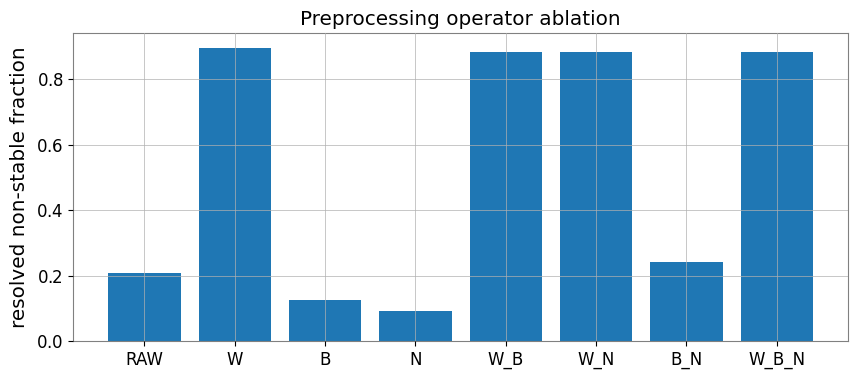

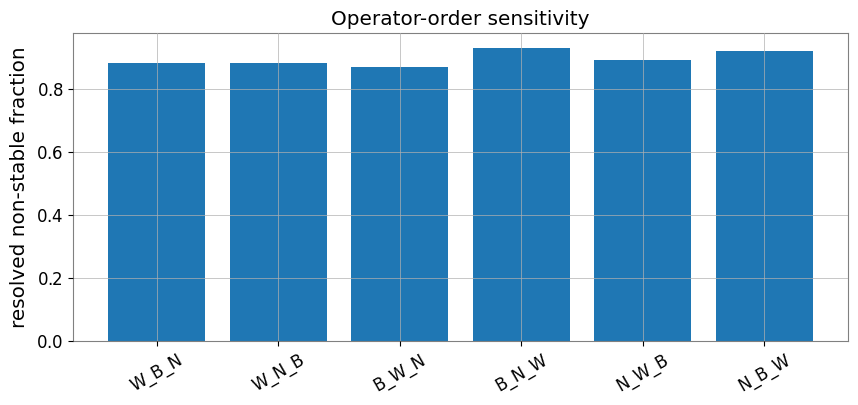

In [8]:

plot_df=ablation_df[ablation_df.status=="OK"].copy()

plt.figure(figsize=(10,4))
plt.bar(plot_df.pipeline,plot_df.nonstable_fraction_resolved)
plt.ylabel("resolved non-stable fraction")
plt.title("Preprocessing operator ablation")
plt.grid(True,axis="y")
plt.show()

plt.figure(figsize=(10,4))
od=order_df[order_df.status=="OK"]
plt.bar(od.pipeline,od.nonstable_fraction_resolved)
plt.ylabel("resolved non-stable fraction")
plt.title("Operator-order sensitivity")
plt.xticks(rotation=30)
plt.grid(True,axis="y")
plt.show()


## 8 — Phase et amplitude par opérateur

In [9]:

display(
    ablation_df[ablation_df.status=="OK"][
        ["pipeline","median_amp_cv","median_phase_mad",
         "median_complex_dist","nonstable_fraction_resolved"]
    ]
)


,pipeline,median_amp_cv,median_phase_mad,median_complex_dist,nonstable_fraction_resolved
0,RAW,7.766293e-18,0.616780,2.287944e-17,0.208696
1,W,3.575681e-01,0.549386,7.477793e-01,0.895652
2,B,1.633100e-18,0.436551,4.474763e-18,0.126087
3,N,5.450115e-18,0.497745,1.502798e-17,0.091304
4,W_B,3.525881e-01,0.538155,7.355596e-01,0.882609
5,W_N,3.442580e-01,0.655423,7.446133e-01,0.882609
6,B_N,8.971826e-19,0.648612,2.158423e-18,0.243478
7,W_B_N,3.468651e-01,0.623665,7.326728e-01,0.882609


## 9 — Attribution du facteur de prétraitement

On identifie le candidat principal à partir des variations contrôlées de \(f_{\rm nonstable}\).

On distingue aussi un cas `ORDER-INTERACTION-DOMINATED` si la permutation des mêmes opérateurs modifie fortement le résultat.

Ces verdicts restent méthodologiques, pas fondamentaux.


In [10]:

finite_marg=marginal_df[np.isfinite(marginal_df.abs_delta)].copy()

if len(finite_marg):
    top_contrast=str(finite_marg.iloc[0].contrast)
    top_effect=float(finite_marg.iloc[0].abs_delta)
    second_effect=float(finite_marg.iloc[1].abs_delta) if len(finite_marg)>1 else 0.0
else:
    top_contrast=None
    top_effect=np.nan
    second_effect=np.nan

WHITENING_MAIN_EFFECT=max(
    abs(marginal.get("W_vs_RAW",np.nan)),
    abs(marginal.get("W_after_BN",np.nan))
)
BANDPASS_MAIN_EFFECT=max(
    abs(marginal.get("B_vs_RAW",np.nan)),
    abs(marginal.get("B_after_N",np.nan)),
    abs(marginal.get("B_after_W",np.nan))
)
NOTCH_MAIN_EFFECT=max(
    abs(marginal.get("N_vs_RAW",np.nan)),
    abs(marginal.get("N_after_W",np.nan)),
    abs(marginal.get("N_after_WB",np.nan))
)

effects={
    "WHITENING":WHITENING_MAIN_EFFECT,
    "BANDPASS":BANDPASS_MAIN_EFFECT,
    "NOTCH":NOTCH_MAIN_EFFECT,
    "ORDER":ORDER_SPAN
}

effect_df=pd.DataFrame([
    {"factor":k,"effect_size":float(v)}
    for k,v in effects.items() if np.isfinite(v)
]).sort_values("effect_size",ascending=False)

display(effect_df)


,factor,effect_size
0,WHITENING,0.686957
1,BANDPASS,0.152174
2,NOTCH,0.117391
3,ORDER,0.060870


## 10 — Verdict automatique

In [11]:

FINITE_OK=bool(
    len(ablation_df[ablation_df.status=="OK"])>=6
    and len(order_df[order_df.status=="OK"])>=4
)

if not FINITE_OK or len(effect_df)==0:
    FINAL_STATUS="UNRESOLVED"
    DOMINANT_FACTOR=None
else:
    DOMINANT_FACTOR=str(effect_df.iloc[0].factor)
    top=float(effect_df.iloc[0].effect_size)
    second=float(effect_df.iloc[1].effect_size) if len(effect_df)>1 else 0.0

    clearly_dominant=bool(
        top>=0.15 and
        top>=1.5*(second+1e-12)
    )

    if clearly_dominant:
        mapping={
            "WHITENING":"WHITENING-DOMINATED",
            "BANDPASS":"BANDPASS-DOMINATED",
            "NOTCH":"NOTCH-DOMINATED",
            "ORDER":"ORDER-INTERACTION-DOMINATED"
        }
        FINAL_STATUS=mapping[DOMINANT_FACTOR]
    else:
        FINAL_STATUS="PREPROCESSING-MULTIFACTOR-INTERACTION"

artifact={
    "step":"RACC-C.4-real.2.9",
    "event":"GW150914",
    "question":"Which preprocessing operator transforms T_H1_to_L1(f,t) stationarity?",
    "ablation":ablation_df.to_dict(orient="records"),
    "order_audit":order_df.to_dict(orient="records"),
    "marginal_effects":marginal,
    "factor_effects":effects,
    "dominant_factor":DOMINANT_FACTOR,
    "final_status":FINAL_STATUS,
    "TIMING_VALIDATED":False,
    "D_T_ref":"NOT-AUTHORIZED",
    "REAL3_AUTHORIZED":False,
    "DISPERSION_READY_modified":False,
    "HH_chain_modified":False,
    "core_GVH_modified":False
}

print(json.dumps(artifact,indent=2))


{
  "step": "RACC-C.4-real.2.9",
  "event": "GW150914",
  "question": "Which preprocessing operator transforms T_H1_to_L1(f,t) stationarity?",
  "ablation": [
    {
      "pipeline": "RAW",
      "sequence": "RAW",
      "status": "OK",
      "n_tiles": 384,
      "resolved_fraction": 0.5989583333333334,
      "stable_fraction_resolved": 0.44782608695652176,
      "transition_fraction_resolved": 0.34347826086956523,
      "nonstable_fraction_resolved": 0.20869565217391303,
      "unresolved_fraction": 0.4010416666666667,
      "median_amp_cv": 7.76629343632273e-18,
      "median_phase_mad": 0.6167804341693097,
      "median_complex_dist": 2.287944300400398e-17
    },
    {
      "pipeline": "W",
      "sequence": "W",
      "status": "OK",
      "n_tiles": 384,
      "resolved_fraction": 0.5989583333333334,
      "stable_fraction_resolved": 0.004347826086956522,
      "transition_fraction_resolved": 0.1,
      "nonstable_fraction_resolved": 0.8956521739130435,
      "unresolved_fractio

## 11 — Stop-rule finale

Les verdicts possibles sont :

\[
\boxed{
\texttt{WHITENING-DOMINATED}
\;|\;
\texttt{BANDPASS-DOMINATED}
\;|\;
\texttt{NOTCH-DOMINATED}
\;|\;
\texttt{ORDER-INTERACTION-DOMINATED}
\;|\;
\texttt{PREPROCESSING-MULTIFACTOR-INTERACTION}
\;|\;
\texttt{UNRESOLVED}
}
\]

Si le whitening domine, l'étape suivante devra auditer séparément :

- estimation PSD ;
- fenêtre de bruit ;
- régularisation du PSD ;
- effets de bord ;
- phase induite par la procédure.

Dans tous les cas :

\[
\boxed{
\texttt{TIMING-VALIDATED=False},
\quad
D_T^{ref}=\texttt{NOT-AUTHORIZED},
\quad
\texttt{REAL3-AUTHORIZED=False}
}
\]
